In [111]:

import numpy as np
import pandas as pd
from typing import List, Tuple
from scipy.cluster.hierarchy import fcluster



from scipy.stats import wasserstein_distance
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
from typing import Literal, Optional
import os
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors



In [112]:
import pandas as pd

project_root = Path(".").resolve().parent.parent.parent.parent
print(project_root)
assert project_root.name == "pep-compass"


parents = pd.read_csv(
    project_root
    / "results/data/hydramp/dbaasp/all/dbaasp_clean_leq25.csv"
)
mutants = pd.read_csv(
    project_root
    / "results/mutants/mutants/hydramp/dbaasp/all/dbaasp_clean_parentleq25_direction_threshold=1e-06_token_threshold=0.1_jacobian_mode=approx_jacobian_eps=0.05_leq25.csv"
)


def compute_diff(
    parents_df: pd.DataFrame,
    mutants_df: pd.DataFrame,
    match_col_parents: str,
    match_col_mutants: str,
    value_cols: list[str],
    value_preprocessing: Optional[Literal["log"]],
    add_relative: bool,
) -> pd.DataFrame:
    """
    Compute the difference between the mutants and parents for each value column.
    """
    merged = mutants_df.merge(
        parents_df,
        left_on=match_col_mutants,
        right_on=match_col_parents,
        suffixes=("_mutants", "_parents"),
    )
    if value_preprocessing is None:
        vprep_fn = lambda x: x
    elif value_preprocessing == "log":
        vprep_fn = np.log2
    else:
        raise ValueError(f"Invalid value_preprocessing: {value_preprocessing}")
    if value_preprocessing is None:
        value_preprocessing = ""
    else:
        value_preprocessing = "_" + value_preprocessing

    for value_col in value_cols:
        merged[f"{value_col}{value_preprocessing}_diff"] = vprep_fn(
            merged[f"{value_col}_mutants"]
        ) - vprep_fn(merged[f"{value_col}_parents"])
        if add_relative:
            merged[f"{value_col}{value_preprocessing}_diff_relative"] = merged[
                f"{value_col}{value_preprocessing}_diff"
            ] / vprep_fn(merged[f"{value_col}_parents"])
    return merged

mic_bac_columns = parents.head().columns.tolist()[3:]

diff = compute_diff(
    parents_df=parents,
    mutants_df=mutants,
    match_col_parents="description",
    match_col_mutants="parent_id",
    value_cols=mic_bac_columns,
    value_preprocessing="log",
    add_relative=True,
)


ALL_AA = list("ACDEFGHIKLMNPQRSTVWY")


diff_clean = diff.dropna(subset=["parent", "mutant", "position"]).drop_duplicates(subset=["parent", "mutant", "position"])


mask = (
    (diff_clean["position"] < diff_clean["parent"].str.len()) &
    (diff_clean["position"] < diff_clean["mutant"].str.len())
)
diff_clean = diff_clean[mask]

#possition mask (take only mutations on first/last 7 positions)0

# position_mask = (
#     (diff_clean["position"] < 7) |
#     (diff_clean["position"] >= diff_clean["parent"].str.len() - 7)
#     )
# diff_clean = diff_clean[position_mask]



delta_cols = [col for col in diff.columns if col.endswith("_diff")]

diff_clean["parent_aa"] = diff_clean.apply(lambda r: r["parent"][r["position"]], axis=1)
diff_clean["mutant_aa"] = diff_clean.apply(lambda r: r["mutant"][r["position"]], axis=1)

diff_clean = diff_clean[diff_clean["parent_aa"] != diff_clean["mutant_aa"]]

mutation_matrix = pd.DataFrame(
    [[[] for _ in ALL_AA] for _ in ALL_AA],
    index=ALL_AA,
    columns=ALL_AA
)

for aa_pair, group in diff_clean.groupby(["parent_aa", "mutant_aa"]):
    p_aa, m_aa = aa_pair
    mutation_matrix.at[p_aa, m_aa] = group[delta_cols].to_numpy()

/home/kjurasz/pep-compass


In [113]:
mutation_matrix_values = mutation_matrix.to_numpy()

In [114]:

def collect_all_values(matrix_cells) -> np.ndarray:
    
    all_vals = []
    # matrix_cells can be a list of lists or a numpy array of object cells
    for row in matrix_cells:
        for cell in row:
            if cell is None:
                continue
            # Each cell may be:
            # - list of floats
            # - numpy array of shape (n, k) with multiple delta columns
            # Normalize to 1D list of floats
            if isinstance(cell, np.ndarray):
                if cell.size == 0:
                    continue
                # Flatten to 1D and extend as floats
                all_vals.extend(cell.flatten().tolist())
            elif isinstance(cell, list):
                if len(cell) == 0:
                    continue
                # If elements are arrays, flatten them
                if len(cell) > 0 and isinstance(cell[0], (np.ndarray, list, tuple)):
                    for elem in cell:
                        arr = np.array(elem).flatten()
                        all_vals.extend(arr.tolist())
                else:
                    all_vals.extend([float(x) for x in cell])
            else:
                # Single scalar value
                try:
                    all_vals.append(float(cell))
                except Exception:
                    pass
    return np.array(all_vals, dtype=float)

def make_bins_equal_width(all_values: np.ndarray, N: int) -> tuple[np.ndarray, float, float]:
    
    if all_values.size == 0:
        raise ValueError("Brak wartości w macierzy — nie można utworzyć binów.")
    # Use 2nd and 98th percentiles to ignore outliers
    p2, p98 = np.percentile(all_values, [2, 98])
    vmin, vmax = float(p2), float(p98)
    if np.isclose(vmin, vmax):
        
        eps = max(1e-6, abs(vmin) * 1e-6 + 1e-6)
        vmin -= eps
        vmax += eps
    bins = np.linspace(vmin, vmax, N + 1)
    return bins, vmin, vmax

# Przykład użycia:
# Use AA×AA mutation matrix values to collect all scalar deltas
all_vals = collect_all_values(mutation_matrix_values)
N_bins = 100
bin_edges, vmin_pct, vmax_pct = make_bins_equal_width(all_vals, N_bins)
bin_edges[:5], bin_edges[-5:]


(array([-0.65999683, -0.64354497, -0.62709311, -0.61064125, -0.59418939]),
 array([0.9193819 , 0.93583377, 0.95228563, 0.96873749, 0.98518935]))

In [115]:
# Cell 5: dla każdej komórki policz histogram wykorzystując bin_edges (AA×AA) z filtrowaniem poza percentylami
def cell_histogram_counts(cell_values, bin_edges: np.ndarray, vmin: float, vmax: float) -> np.ndarray:
    """Zwraca wektor długości N (N = len(bin_edges)-1) z zliczeniami ile elementów wpadło do każdego bina.
       Obsługuje listy i tablice; jeśli puste -> zwracamy wektor zerowy. Przed zliczaniem odrzuca wartości poza [vmin, vmax]."""
    if len(bin_edges) < 2:
        raise ValueError("bin_edges musi zawierać co najmniej 2 elementy")
    # Normalize cell_values to 1D float array
    if cell_values is None:
        return np.zeros(len(bin_edges) - 1, dtype=int)
    if isinstance(cell_values, np.ndarray):
        vals = cell_values.flatten()
    elif isinstance(cell_values, list):
        if len(cell_values) == 0:
            return np.zeros(len(bin_edges) - 1, dtype=int)
        if len(cell_values) > 0 and isinstance(cell_values[0], (np.ndarray, list, tuple)):
            vals = np.concatenate([np.array(x).flatten() for x in cell_values])
        else:
            vals = np.array(cell_values, dtype=float)
    else:
        # single scalar
        try:
            vals = np.array([float(cell_values)])
        except Exception:
            return np.zeros(len(bin_edges) - 1, dtype=int)

    # Filter by percentile range
    if vals.size > 0:
        vals = vals[(vals >= vmin) & (vals <= vmax)]

    if vals.size == 0:
        return np.zeros(len(bin_edges) - 1, dtype=int)

    counts, _ = np.histogram(vals, bins=bin_edges)
    return counts

def matrix_histograms(matrix_cells, bin_edges: np.ndarray, vmin: float, vmax: float) -> List[List[np.ndarray]]:
    """Dla całej macierzy zwraca macierz histogramów: (rows x cols), gdzie każda komórka to np.ndarray z counts.
       `matrix_cells` może być listą list lub numpy array (np.ndarray) obiektów. Wartości poza [vmin, vmax] są ignorowane.
    """
    hist_matrix = []
    for row in matrix_cells:
        hist_row = [cell_histogram_counts(cell, bin_edges, vmin, vmax) for cell in row]
        hist_matrix.append(hist_row)
    return hist_matrix


hist_matrix = matrix_histograms(mutation_matrix_values, bin_edges, vmin_pct, vmax_pct)

len(hist_matrix), len(hist_matrix[0]), hist_matrix[0][0].shape
hist_matrix[2][0]  


array([ 59,  70,  55,  71,  75,  69,  62,  63,  84,  77,  82,  95,  87,
        94, 121, 109, 107, 134, 152, 177, 187, 181, 208, 223, 240, 275,
       233, 238, 255, 236, 289, 312, 305, 332, 355, 350, 407, 385, 385,
       559, 438, 224, 141,  92,  53,  44,  41,  31,  19,  14,  18,  13,
         6,   9,   8,   4,   8,   9,   4,   5,   4,   2,   5,   1,   5,
         2,   0,   1,   0,   0,   3,   0,   0,   0,   0,   0,   0,   1,
         2,   0,   3,   0,   1,   0,   2,   0,   0,   1,   1,   1,   1,
         0,   0,   0,   0,   0,   0,   0,   0,   0])

In [116]:

def flatten_hist_matrix(hist_matrix: List[List[np.ndarray]], aa_labels: List[str]) -> Tuple[np.ndarray, List[Tuple[str,str]]]:
    
    idx_map = []
    H_list = []
    n = len(hist_matrix)
    for i in range(n):
        row = hist_matrix[i]
        for j in range(len(row)):
            if i == j:
                continue  # ignore diagonal (same AA)
            hist = row[j]
            H_list.append(hist.astype(float))
            idx_map.append((aa_labels[i], aa_labels[j]))
    H = np.vstack(H_list)  # shape (M, N) after diagonal removal
    return H, idx_map

# AA labels from the global ALL_AA and hist_matrix built earlier
H, idx_map = flatten_hist_matrix(hist_matrix, ALL_AA)
H.shape  


(380, 100)

In [117]:
def normalize_histograms(H: np.ndarray, kind: str = 'prob') -> np.ndarray:
    """Normalize each row of H.
       kind='prob' -> sum of row == 1 (postacie prawdopodobieństw), równe 0->0
       kind='count' -> pozostawia counts (brak normalizacji)
    """
    if kind == 'count':
        return H
    elif kind == 'prob':
        row_sums = H.sum(axis=1, keepdims=True)
        # unikamy dzielenia przez zero: jeśli suma 0 -> pozostawiamy 0
        row_sums[row_sums == 0] = 1.0
        return H / row_sums
    else:
        raise ValueError("Unknown kind")
    
H_norm = normalize_histograms(H, kind='count')


In [118]:
def pairwise_wasserstein(H: np.ndarray, bin_edges: np.ndarray) -> np.ndarray:
    """
    H: (M, N) histogramy (po normalizacji lub nie)
    bin_edges: N+1 krawędzi → wyciągamy z nich bin_centers
    Zwraca macierz (M, M) odległości Wassersteina.
    """
    M, N = H.shape
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    D = np.zeros((M, M), dtype=float)

    for i in range(M):
        w_i = H[i]
        sum_i = w_i.sum()

        for j in range(i+1, M):
            w_j = H[j]
            sum_j = w_j.sum()

            # --- CASE 1: obie komórki puste ---
            if sum_i == 0 and sum_j == 0:
                d = 0.0

            # --- CASE 2: jedna pusta ---
            elif sum_i == 0 and sum_j > 0:
                # odległość między "nic" a rozkładem j → średnia odległość do bin_centers
                d = np.average(np.abs(bin_centers - np.average(bin_centers, weights=w_j)),
                               weights=w_j)

            elif sum_i > 0 and sum_j == 0:
                d = np.average(np.abs(bin_centers - np.average(bin_centers, weights=w_i)),
                               weights=w_i)

            # --- CASE 3: oba histogramy niepuste → klasyczny Wasserstein ---
            else:
                d = wasserstein_distance(
                    bin_centers, bin_centers,
                    u_weights=w_i,
                    v_weights=w_j
                )

            D[i, j] = d
            D[j, i] = d

    return D


D = pairwise_wasserstein(H_norm, bin_edges)
D.shape  # (400, 400)
# przykład: min/max distances
D.min(), D.max()


(0.0, 0.7501572146773884)

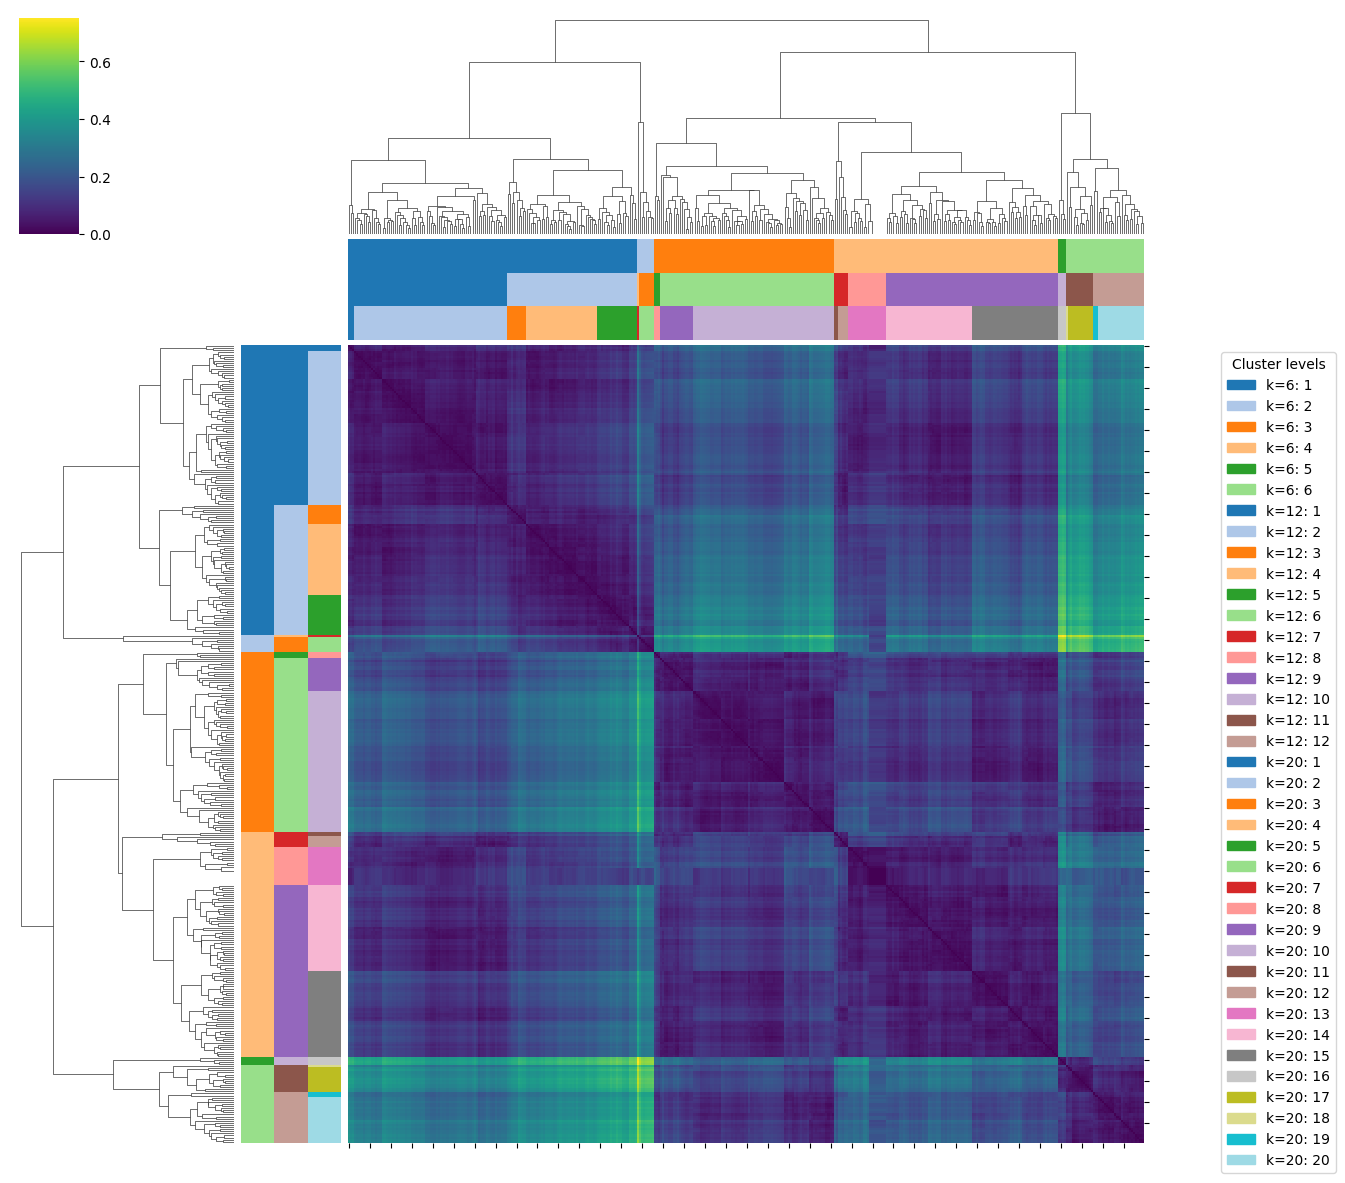

In [134]:
def cluster_and_plot(D, idx_map, method="average", n_clusters=20, figsize=(12,12)):
    """
    D         — macierz odległości (M x M) po usunięciu diagonalnych par
    idx_map   — lista (aa_i, aa_j) opisująca kierunek mutacji (unused for labels)
    method    — metoda linkage
    n_clusters — liczba klastrów lub lista poziomów klastrów (np. [6, 12, 20])
    Pokazuje clustermap oraz paski kolorów z identyfikatorami klastrów dla wielu poziomów.
    """
    import matplotlib.patches as mpatches
    import numpy as np
    import pandas as pd

    # --- condensed distance matrix dla linkage ---
    D_condensed = squareform(D)

    # --- compute hierarchical clustering ---
    Z = linkage(D_condensed, method=method)

    # --- normalizuj n_clusters na listę ---
    if isinstance(n_clusters, int):
        levels = [n_clusters]
    else:
        levels = list(n_clusters)

    # --- DataFrame do heatmapy (bez etykiet, tylko indeksy) ---
    df_dist = pd.DataFrame(D)

    # --- przygotuj kolory dla wielu poziomów ---
    row_colors_levels = []
    legends = []
    for lvl_idx, k in enumerate(levels):
        clusters_k = fcluster(Z, k, criterion='maxclust')
        unique_k = sorted(set(clusters_k))
        # paleta na poziom:
        palette_k = sns.color_palette("tab20", n_colors=max(20, len(unique_k)))
        color_map_k = {cl: palette_k[i % len(palette_k)] for i, cl in enumerate(unique_k)}
        row_colors_k = pd.Series([color_map_k[cl] for cl in clusters_k])
        row_colors_levels.append(row_colors_k)
        # legenda dla poziomu k:
        handles_k = [mpatches.Patch(color=color_map_k[cl], label=f"k={k}: {cl}") for cl in unique_k]
        legends.append(handles_k)

    # --- Clustermap z gotowymi dendrogramami i wieloma paskami klastrów ---
    g = sns.clustermap(
        df_dist,
        row_linkage=Z,
        col_linkage=Z,
        cmap="viridis",
        row_colors=row_colors_levels,
        col_colors=row_colors_levels,
        figsize=figsize
    )

    # Ukryj etykiety osi
    plt.setp(g.ax_heatmap.get_xticklabels(), visible=False)
    plt.setp(g.ax_heatmap.get_yticklabels(), visible=False)

    # Dodaj legendy dla poziomów (połącz w jedną legendę)
    all_handles = [h for handles in legends for h in handles]
    g.ax_heatmap.legend(all_handles, [h.get_label() for h in all_handles], title="Cluster levels", loc="upper right", bbox_to_anchor=(1.25, 1))

    plt.show()

    # Zwróć Z oraz przypisania dla ostatniego poziomu (największe k) oraz słownik dla wszystkich
    clusters_last = fcluster(Z, levels[-1], criterion='maxclust')
    clusters_by_level = {k: fcluster(Z, k, criterion='maxclust') for k in levels}
    return Z, clusters_last, clusters_by_level

# --- Uruchomienie ---
Z, clusters, clusters_by_level = cluster_and_plot(D, idx_map, method="average", n_clusters=[6, 12, 20])

In [135]:
import numpy as np
from collections import defaultdict

def compute_cluster_centroids(hist_vectors, clusters):
    """
    hist_vectors : array M x N (histogramy)
    clusters     : array długości M (przypisanie klastra)
    """
    cluster_dict = defaultdict(list)

    for h, cl in zip(hist_vectors, clusters):
        cluster_dict[cl].append(h)

    centroids = {}
    for cl, vecs in cluster_dict.items():
        centroids[cl] = np.mean(np.vstack(vecs), axis=0)

    return centroids


In [136]:
import matplotlib.pyplot as plt
import numpy as np

def plot_centroids_with_bin_centers(centroids, bin_edges, normalize=True):

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    K = len(centroids)

    plt.figure(figsize=(12, 3*K))

    for i, (cl, h) in enumerate(sorted(centroids.items()), 1):
        if normalize:
            h_plot = h / h.sum() if h.sum() > 0 else h
        else:
            h_plot = h

        plt.subplot(K, 1, i)
        plt.bar(bin_centers, h_plot, width=np.diff(bin_edges), color="steelblue", edgecolor='black', align='center')
        plt.title(f"Centroid of cluster {cl}")
        plt.xlabel("MIC")
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


In [137]:
def plot_cluster_matrix(idx_map, clusters, aa_labels: List[str]):
    """
    Render a square AA×AA matrix of cluster assignments:
    - Off-diagonal: cluster ID for (aa_i -> aa_j)
    - Diagonal: NaN (empty)
    Axes labeled with amino acids.
    Uses one discrete color per cluster with clear legend ticks.
    """
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors

    # Initialize AA×AA matrix with NaN on diagonal
    A = len(aa_labels)
    mat = np.full((A, A), np.nan, dtype=float)

    # Fill off-diagonal from idx_map/clusters
    label_to_idx = {aa: i for i, aa in enumerate(aa_labels)}
    for cl, (aa_i, aa_j) in zip(clusters, idx_map):
        i = label_to_idx[aa_i]
        j = label_to_idx[aa_j]
        if i != j:
            mat[i, j] = cl

    df = pd.DataFrame(mat, index=aa_labels, columns=aa_labels)

    # Prepare discrete colormap: one color per cluster
    unique_clusters = sorted({int(c) for c in clusters})
    # Use a categorical palette with enough distinct colors
    palette = sns.color_palette("tab20", n_colors=max(20, len(unique_clusters)))
    cmap = mcolors.ListedColormap(palette[:len(unique_clusters)])
    # BoundaryNorm to align colors to integer cluster IDs
    boundaries = np.arange(min(unique_clusters), max(unique_clusters) + 2) - 0.5
    norm = mcolors.BoundaryNorm(boundaries, cmap.N)

    # Mask NaN diagonal for cleaner look
    mask = df.isna()

    plt.figure(figsize=(8, 8))
    ax = sns.heatmap(
        df,
        cmap=cmap,
        norm=norm,
        mask=mask,
        annot=False,
        cbar=True,
        linewidths=0.5,
        linecolor='white'
    )
    ax.set_title("Cluster assignment map (AA×AA, diagonal empty)")
    ax.set_xlabel("Mutant AA")
    ax.set_ylabel("Parent AA")
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    # Configure colorbar ticks to show cluster IDs
    cbar = ax.collections[0].colorbar
    cbar.set_ticks(unique_clusters)
    cbar.set_ticklabels([str(c) for c in unique_clusters])
    cbar.set_label("Cluster ID")

    plt.show()

    return df

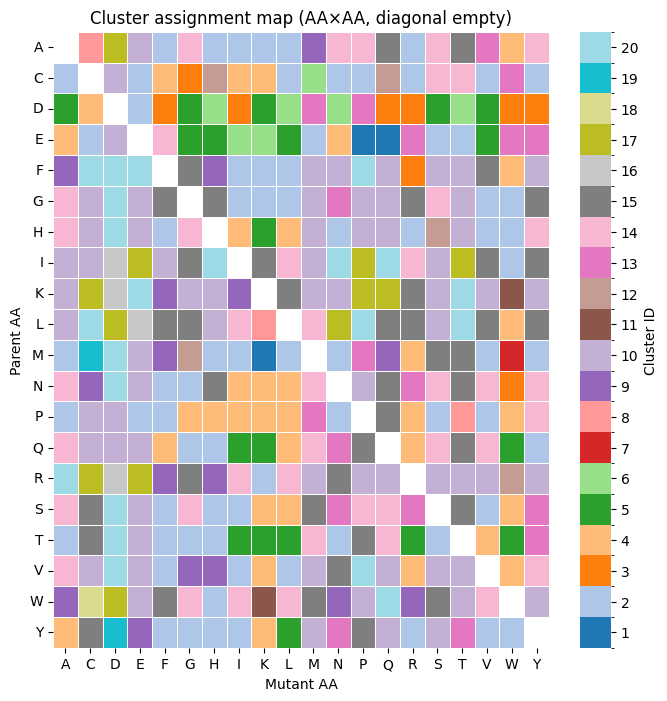

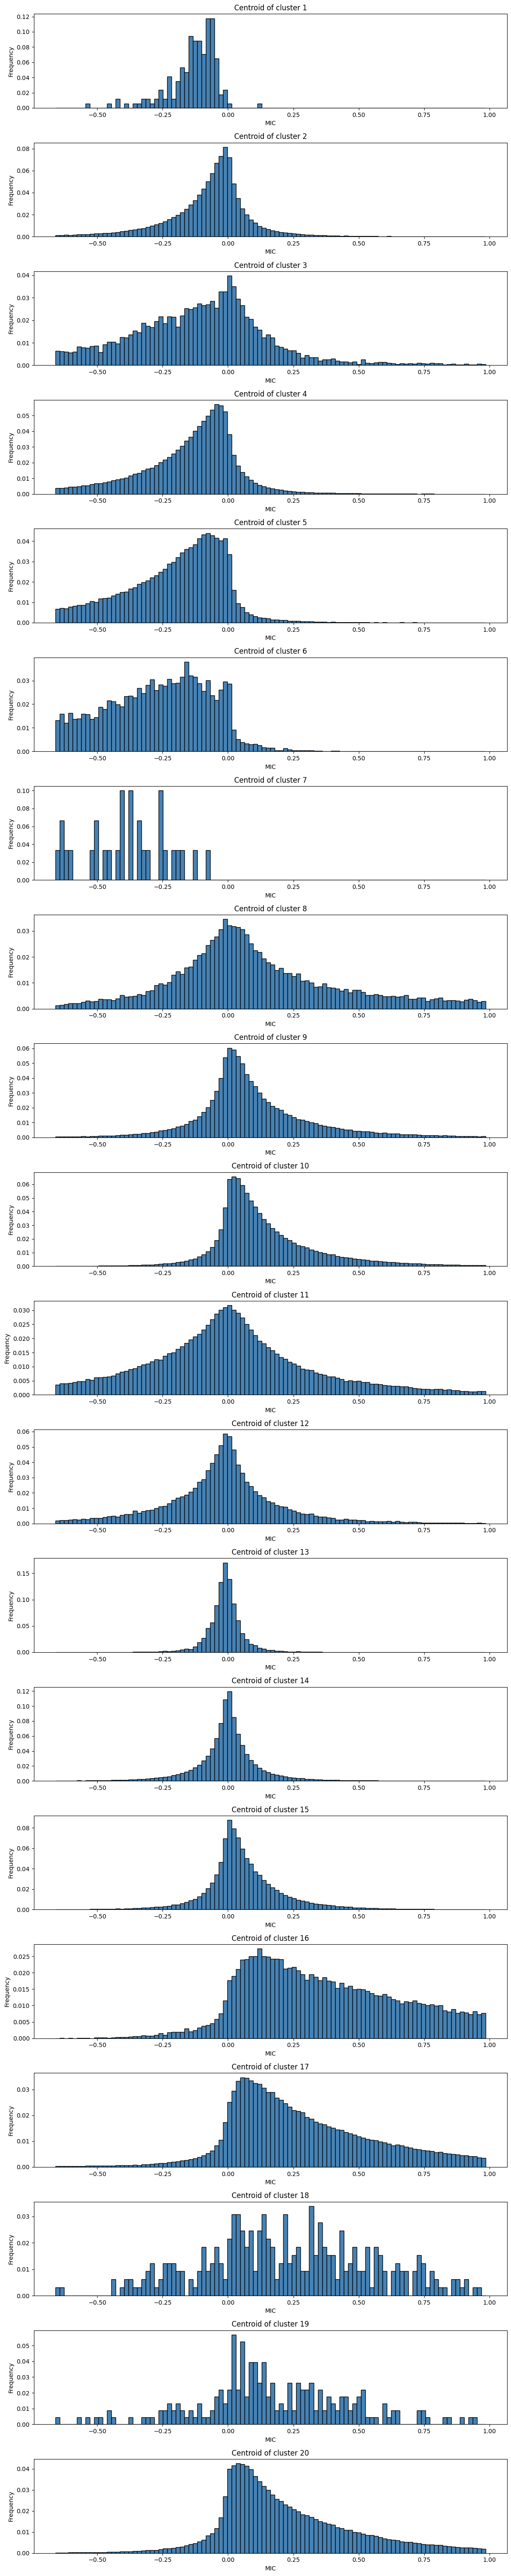

In [138]:
centroids = compute_cluster_centroids(H_norm, clusters)

# Heatmap of AA×AA cluster assignments with empty diagonal
assignments_df = plot_cluster_matrix(idx_map, clusters, aa_labels=ALL_AA)

plot_centroids_with_bin_centers(centroids, bin_edges, normalize=True)

